# Defining libraries and loading data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import os
import time
from pathlib import Path
import sys
import pandas as pd
from tqdm import tqdm
import json


import torchvision.utils as vutils
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from dataclasses import dataclass

In [ ]:
DATA_DIR = "./results/data"
OUTPUT_DIR = "./results/outputs"

BATCH_SIZE = 128
NUM_WORKERS = 2
LEARNING_RATE = 1e-3
LATENT_DIM = 128
dev_EPOCHS = 1
prod_EPOCHS = 100

# VAE specific variables
hidden_channels = (512, 256)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
KAGGLE_MODEL_DIR = Path("./Kaggle/Kaggle_run_final")

Kaggle\Kaggle_run_final


In [3]:
#Make sure GPU torch is instaled and available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("PyTorch version:", torch.__version__) # should be 2.0.1 or later for CUDA support
print("torch version:", torch.version.cuda) # should show CUDA version if available
#Check if GPU is available and set device accordingly
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
PyTorch version: 2.11.0+cu128
torch version: 12.8
GPU: Quadro T1000 with Max-Q Design


## Loading the Data

In [4]:

def get_datasets(data_dir="./data", dataset_name="mnist"):
    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    if dataset_name == "mnist":
        train_set = datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.MNIST(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 1, 28

    elif dataset_name == "fashion-mnist":
        train_set = datasets.FashionMNIST(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.FashionMNIST(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 1, 28

    elif dataset_name == "cifar10":
        train_set = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 3, 32

    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    return train_set, test_set, in_channels, input_size

def get_dataloaders(data_dir="./data", dataset_name="mnist", batch_size=128, num_workers=2):
    train_set, test_set, in_channels, input_size = get_datasets(data_dir, dataset_name)

    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True
    )
    test_loader = DataLoader(
        test_set, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True
    )

    return train_loader, test_loader, in_channels, input_size

def show_batch(images, n=8, title="Batch"):
    images = images[:n].cpu()
    grid = vutils.make_grid(images, nrow=n, padding=2)
    plt.figure(figsize=(n * 1.5, 2))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray" if images.shape[1] == 1 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()

def _infer_vae_config_from_state_dict(state_dict, fallback_config=None):
    fallback_config = dict(fallback_config or {})
    inferred = {}

    # Legacy save format used image shape, not flattened input_dim.
    if "input_dim" not in fallback_config:
        if "input_size" in fallback_config and "in_channels" in fallback_config:
            inferred["input_dim"] = int(fallback_config["input_size"]) ** 2 * int(fallback_config["in_channels"])

    if "fc1.weight" in state_dict:
        h0 = int(state_dict["fc1.weight"].shape[0])
        inferred["input_dim"] = int(state_dict["fc1.weight"].shape[1])
        
        # Check if hidden_channels is a tuple (new format) or single value (legacy)
        if "enc_fc2.weight" in state_dict:
            h1 = int(state_dict["enc_fc2.weight"].shape[0])
            inferred["hidden_channels"] = (h0, h1)
        else:
            # Fallback to single value for backward compatibility
            inferred["hidden_channels"] = h0

    if "enc_logvar.weight" in state_dict:
        inferred["latent_dim"] = int(state_dict["enc_logvar.weight"].shape[0])
    elif "enc_mean.weight" in state_dict:
        inferred["latent_dim"] = int(state_dict["enc_mean.weight"].shape[0])

    # Output size is a robust signal for flattened image dimensionality.
    if "dec_output.weight" in state_dict:
        inferred["input_dim"] = int(state_dict["dec_output.weight"].shape[0])

    merged = {**fallback_config, **inferred}

    if "dataset_name" not in merged and "input_dim" in merged:
        if merged["input_dim"] == 3072:
            merged["dataset_name"] = "cifar10"
        elif merged["input_dim"] == 784:
            merged["dataset_name"] = "mnist"

    return merged

import inspect

def load_trained_vae(
    checkpoint_path,
    model_class,
    device="cpu",
    load_best=False,
):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    model_config = checkpoint.get("model_config", {})

    state_dict = checkpoint.get("best_model_state_dict") if (load_best and checkpoint.get("best_model_state_dict") is not None) else checkpoint.get("model_state_dict")
    if state_dict is None:
        raise ValueError(f"No model state dict found in checkpoint: {checkpoint_path}")

    # Make loading robust to legacy/incorrect config metadata by inferring dims from weights.
    effective_config = _infer_vae_config_from_state_dict(state_dict, model_config)

    valid_params = inspect.signature(model_class.__init__).parameters
    filtered_model_config = {
        k: v for k, v in effective_config.items()
        if k in valid_params and k != "self"
    }

    model = model_class(**filtered_model_config).to(device)
    model.load_state_dict(state_dict)

    # Backward compatibility with older executed class definitions.
    if not hasattr(model, "dataset_name"):
        model.dataset_name = str(effective_config.get("dataset_name", "mnist")).lower()

    optimizer_state = checkpoint.get("optimizer_state_dict", None)
    history = checkpoint.get("history", {})
    extra_info = checkpoint.get("extra_info", {})

    return {
        "model": model,
        "optimizer_state_dict": optimizer_state,
        "history": history,
        "model_config": effective_config,
        "extra_info": extra_info,
    }


In [5]:
mnist_train, mnist_test, mnist_in_channels, mnist_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
fashion_mnist_train, fashion_mnist_test, fashion_mnist_in_channels, fashion_mnist_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="fashion-mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
cifar10_train, cifar10_test, cifar10_in_channels, cifar10_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="cifar10",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

100%|██████████| 9.91M/9.91M [00:03<00:00, 3.26MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 310kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.36MB/s]
100%|██████████| 26.4M/26.4M [00:18<00:00, 1.45MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.21MB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.9MB/s]
100%|██████████| 170M/170M [01:24<00:00, 2.01MB/s] 


torch.Size([128, 1, 28, 28]) torch.Size([128])


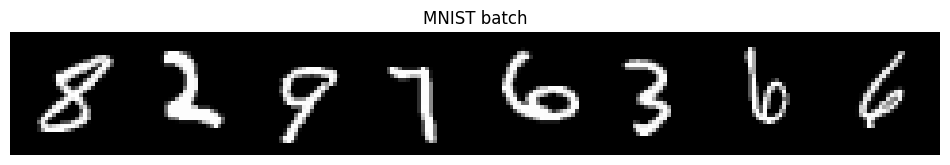

torch.Size([128, 1, 28, 28]) torch.Size([128])


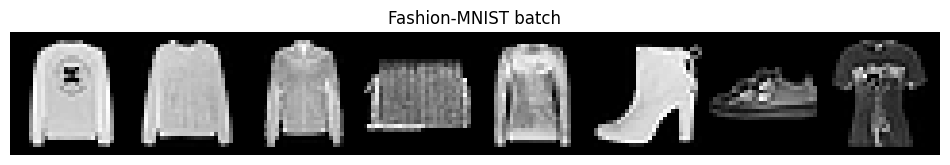

torch.Size([128, 3, 32, 32]) torch.Size([128])


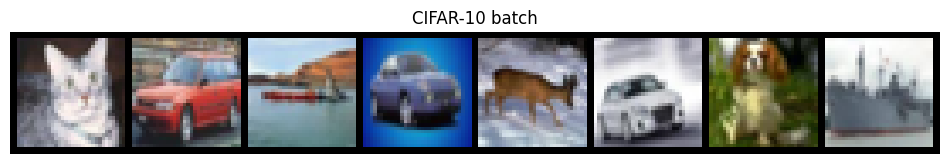

In [6]:
mnist_images, labels = next(iter(mnist_train))
fashion_mnist_images, labels1 = next(iter(fashion_mnist_train))
cifar10_images, labels2 = next(iter(cifar10_train))

print(mnist_images.shape, labels.shape)
show_batch(mnist_images, title="MNIST batch")
print(fashion_mnist_images.shape, labels1.shape)
show_batch(fashion_mnist_images, title="Fashion-MNIST batch")
print(cifar10_images.shape, labels2.shape)
show_batch(cifar10_images, title="CIFAR-10 batch")

## Defining the classes ConvVAE and VAE (linear)

In [7]:
class ConvVAE(nn.Module):
    """
    Convolutional Variational Autoencoder.
    """
    def __init__(self, in_channels, input_size, latent_dim=64, dataset_name="mnist"):
        super(ConvVAE, self).__init__()
        
        self.latent_dim = latent_dim
        self.dataset_name = dataset_name.lower()

        # ==========================================
        # 1. Input Size Type-Check
        # ==========================================
        # If your dataloader returns an int (e.g., 28), convert it to (28, 28)
        if isinstance(input_size, int):
            self.img_height = input_size
            self.img_width = input_size
        else:
            self.img_height = input_size[0]
            self.img_width = input_size[1]


        # ==========================================
        # ENCODER (Conv2d downsamples the image)
        # ==========================================
        # Formula for output size: [(W - Kernel + 2*Pad) / Stride] + 1
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.enc_conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, stride=2, padding=1)
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        
        
        # CIFAR-10 is larger, so we add an extra conv layer to better downsample it before the linear layers
        if self.dataset_name == "cifar10":
            self.enc_conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
            
        dummy_x = torch.zeros(1, in_channels, self.img_height, self.img_width)
        dummy_out = self.enc_conv2(self.enc_conv1(dummy_x))

        if self.dataset_name == "cifar10":
            dummy_out = self.enc_conv3(dummy_out)
        
        # Save the shape before flattening so the decoder knows how to unflatten it later
        self.conv_shape = dummy_out.shape[1:] 
        self.flattened_size = dummy_out.numel()
        # -------------------------------------
        
        # Latent space mappings
        self.enc_mean = nn.Linear(self.flattened_size, latent_dim)
        self.enc_logvar = nn.Linear(self.flattened_size, latent_dim)
        
        # ==========================================
        # DECODER (ConvTranspose2d upsamples the image)
        # ==========================================
        
        self.dec_fc = nn.Linear(latent_dim, self.flattened_size)
        if (self.dataset_name == "cifar10"):
            self.dec_conv0 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1)
        
        self.dec_conv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec_conv2 = nn.ConvTranspose2d(32, in_channels, kernel_size=3, stride=2, padding=1, output_padding=1)

    def encode(self, x):
        h = self.leaky_relu(self.enc_conv1(x))
        h = self.leaky_relu(self.enc_conv2(h))
        if (self.dataset_name == "cifar10"):
            h = self.leaky_relu(self.enc_conv3(h))
            
        # Flatten for the linear layer
        h_flat = h.view(h.size(0), -1)
        mean = self.enc_mean(h_flat)
        logvar = self.enc_logvar(h_flat)
        return mean, logvar
        
    def reparameterize(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + std * eps
        
    def decode(self, z):
        # 1. Map latent vector back to the flattened spatial size
        h = self.leaky_relu(self.dec_fc(z))
        
        # 2. Reshape back to 3D tensor (Channels, Height, Width)
        h = h.view(h.size(0), *self.conv_shape)

        if (self.dataset_name == "cifar10"):
            h = self.leaky_relu(self.dec_conv0(h))
        
        # 3. Upsample back to original image size
        h = self.leaky_relu(self.dec_conv1(h))
        
        # No ReLU on the final output, use Sigmoid (for MNIST/Fashion) or Tanh (if CIFAR is normalized -1 to 1)
        if self.dataset_name == "cifar10":
            x_hat = torch.tanh(self.dec_conv2(h))
        else:
            x_hat =  self.dec_conv2(h)#torch.sigmoid(self.dec_conv2(h))
        return x_hat

    def forward(self, x):
        # Notice we NO LONGER flatten the input 'x' here! It stays as a 2D image.
        mean, logvar = self.encode(x)
        z = self.reparameterize(mean, logvar)
        x_hat = self.decode(z)
        
        return x_hat, mean, logvar

In [8]:
class VAE(nn.Module):
    """
    Standard Variational Autoencoder using Linear (Fully Connected) layers.
    """
    def __init__(self, input_dim=784, hidden_channels=(512, 256), latent_dim=32, dataset_name="mnist"):
        super(VAE, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_channels = hidden_channels
        self.latent_dim = latent_dim
        self.dataset_name = dataset_name.lower()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_channels[0]) #input to hidden
        self.enc_fc2 = nn.Linear(hidden_channels[0], hidden_channels[1]) #hidden to hidden

        # the encoder outputs the mean and log variance for the latent space
        self.enc_mean = nn.Linear(hidden_channels[1], latent_dim) #hidden to mean
        self.enc_logvar = nn.Linear(hidden_channels[1], latent_dim) #hidden to logvar

        # Decoder
        self.dec_fc1 = nn.Linear(latent_dim, hidden_channels[1]) #latent to hidden
        self.dec_fc2 = nn.Linear(hidden_channels[1], hidden_channels[0]) #hidden to hidden
        self.dec_output = nn.Linear(hidden_channels[0], input_dim) #hidden to output

        self.leaky_relu = nn.LeakyReLU(0.2) #LeakyReLU activation function


    def encode(self, x):
        """Encodes the input into the latent space, returning the mean and log variance."""
        h = self.leaky_relu(self.fc1(x))
        h = self.leaky_relu(self.enc_fc2(h))
        mean = self.enc_mean(h)
        logvar = self.enc_logvar(h)
        return mean, logvar
    
    def reparameterize(self, mean, logvar):
        """Applies reparameterization trick z = mean + std * eps, where eps ~ N(0, 1)
        This allows backpropagation through the stochastic sampling process."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + std * eps
    

    def decode(self, z):
        """Decodes the latent variable back to the input space."""
        h = self.leaky_relu(self.dec_fc1(z))
        h = self.leaky_relu(self.dec_fc2(h))
        # tanh to get output in [-1, 1] (if CIFAR is normalized) or sigmoid for [0, 1] (if MNIST/Fashion)
        if self.dataset_name == "cifar10":
            x_hat = torch.tanh(self.dec_output(h))
        else:
            x_hat = torch.sigmoid(self.dec_output(h)) #sigmoid to get output in [0, 1]
        return x_hat
    
    def forward(self, x):
        # Flatten the input image to a vector
        BATCH_SIZE, C, H, W = x.size() #C = channels, H = height, W = width
        x_flat = x.view(BATCH_SIZE, -1) # Flatten the image to a vector

        # Encode the input to get mean and log variance
        mean, logvar = self.encode(x_flat)

        # Sample from the distribution using the reparameterization trick
        z = self.reparameterize(mean, logvar)

        # Decode the latent variable to reconstruct the input
        x_hat = self.decode(z)

        #reshape the output back to the original image shape
        x_hat = x_hat.view(BATCH_SIZE, C, H, W)
        return x_hat, mean, logvar

# Loading saved CONVVAE models

In [12]:
vae_checkpoint_path = Path(str(KAGGLE_MODEL_DIR/ "VAE_final_Nathan"/ "saved_models/VAE"))

vae_mnist_fp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "MNIST" / "vae_mnist_FP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
    
)

vae_mnist_mp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "MNIST" / "vae_mnist_MP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vae_fmnist_fp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "FMNIST" / "vae_fashionmnist_FP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)

vae_fmnist_mp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "FMNIST" / "vae_fashionmnist_MP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vae_cifar10_fp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "CIFAR" / "vae_cifar10_FP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vae_cifar10_mp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path/ "CIFAR" / "vae_cifar10_MP.pt"),
    model_class=ConvVAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)




# Loading saved VAE (linear) models

In [15]:
### Linear models'
vae_checkpoint_path_linear = Path(str(KAGGLE_MODEL_DIR / "VAE_final_Nathan"/ "saved_models/VAE"))

vae_mnist_linear_fp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path_linear/ "MNIST" / "vae_mnist_linear_FP.pt"),
    model_class=VAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)

vae_mnist_linear_mp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path_linear/ "MNIST" / "vae_mnist_linear_MP.pt"),
    model_class=VAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vae_fmnist_linear_fp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path_linear/ "FMNIST" / "vae_fashionmnist_linear_FP.pt"),
    model_class=VAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)

vae_fmnist_linear_mp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path_linear/ "FMNIST" / "vae_fashionmnist_linear_MP.pt"),
    model_class=VAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,            # set True if you want best_model_state_dict
)
vae_cifar10_linear_fp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path_linear/ "CIFAR" / "vae_cifar10_linear_FP.pt"),
    model_class=VAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,    # set True if you want best_model_state_dict
)
vae_cifar10_linear_mp = load_trained_vae(
    checkpoint_path=str(vae_checkpoint_path_linear/ "CIFAR" / "vae_cifar10_linear_MP.pt"),
    model_class=VAE,   # replace with your actual VAE class name
    device=device,
    load_best=True,    # set True if you want best_model_state_dict
)

# Plotting functions

In [55]:
def plot_vae_history(history_mp, history_fp, subtitle="", main_title=""):
    """
    Plots the training curves for Total Loss, BCE, and KLD in 1 plot, combined with the FP history for comparison.
    """
    epochs = range(1, len(history_mp['train_loss']) + 1)
    plt.figure(figsize=(14, 5))
    #plot a main title above both subplots, with fontsize 22
    plt.suptitle(main_title, fontsize=22)
    # Subplot 1: Loss FP
    plt.subplot(1, 2, 1)
    
    plt.plot(epochs, history_fp['train_loss'], label='Total Loss (FP)', color='r', linewidth=3, marker='s', markevery=3) # add square markers for FP, for every 5 epochs
    plt.plot(epochs, history_fp['bce_loss'], label='BCE Loss (FP)', color='darkorange', linewidth=2,marker='s', markevery=3)
    plt.plot(epochs, history_fp['kld_loss'], label='KL Divergence (FP)', color='gold', linewidth=2, marker='s', markevery=3)
    plt.title(f"VAE Training Loss Curves {subtitle} (FP)", fontsize=20)
    plt.xlabel("Epochs", fontsize=16)
    plt.ylabel("Loss", fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # Subplot 2: Loss MP
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_mp['train_loss'], label='Total Loss (MP)', color='g', linewidth=3, marker='o', markevery=3) # add dots marker='o'
    plt.plot(epochs, history_mp['bce_loss'], label='BCE Loss (MP)', color='teal', linewidth=2, marker='o', markevery=3)
    plt.plot(epochs, history_mp['kld_loss'], label='KL Divergence (MP)', color='lightgreen', linewidth=2, marker='o', markevery=3)
    plt.title(f"VAE Training Loss Curves {subtitle} (MP)", fontsize=20)
    plt.xlabel("Epochs", fontsize=16)
    plt.ylabel("Loss", fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

def to_display_tensor(x, dataset_name="mnist"):
    x = x.detach().cpu()
    dataset_name = dataset_name.lower()

    if dataset_name.lower() == "cifar10":
        x_min = x.min().item()
        x_max = x.max().item()

        # Case 1: already displayable
        if -0.1 <= x_min and x_max <= 1.0:
            return x.clamp(0.0, 1.0)

        # Case 2: tanh-style output
        if -1.0 <= x_min and x_max <= 1.0:
            return ((x + 1.0) / 2.0).clamp(0.0, 1.0)
    elif x.min().item() < 0.0 or x.max().item() > 1.0:
        x = torch.sigmoid(x)

    return x.clamp(0, 1)

def generate_vae_images(model, num_images=16, device='cpu'):
    """
    Sample latent vectors and decode them to images for MNIST/Fashion-MNIST/CIFAR-10.
    Works with decoders that return either flattened tensors [B, D] or image tensors [B, C, H, W].
    """
    model.eval()
    z_random = torch.randn(num_images, model.latent_dim).to(device) #
    z_random = z_random.float() # Ensure the random latent vectors are in float32 for decoding

    # generate images from test set mnist_test and plot them in a grid using torchvision.utils.make_grid


    with torch.no_grad():
        generated = model.decode(z_random)

        if generated.ndim == 4:
            # Decoder already returned [B, C, H, W] (e.g., ConvVAE).
            generated_images = to_display_tensor(generated, getattr(model, "dataset_name", "mnist"))
        elif generated.ndim == 2:
            # Decoder returned flattened outputs [B, D] (e.g., FC VAE).
            dataset_name = getattr(model, "dataset_name", "mnist").lower()
            in_channels = 3 if dataset_name == "cifar10" else 1

            if hasattr(model, "img_height") and hasattr(model, "img_width"):
                h, w = model.img_height, model.img_width
            else:
                flat_dim = generated.size(1)
                pixels_per_channel = flat_dim // in_channels
                side = int(np.sqrt(pixels_per_channel))
                if side * side * in_channels != flat_dim:
                    raise ValueError(
                        f"Cannot infer image shape from flattened decoder output with dim={flat_dim}."
                    )
                h, w = side, side

            generated_images = generated.view(num_images, in_channels, h, w)
        else:
            raise ValueError(
                f"Unexpected decoder output shape {tuple(generated.shape)}. Expected 2D or 4D tensor."
            )

    nrow = max(1, int(np.sqrt(num_images)))
    grid = vutils.make_grid(generated_images.cpu(), nrow=nrow, padding=2)

    plt.figure(figsize=(6, 6))
    if generated_images.size(1) == 1:
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    else:
        plt.imshow(grid.permute(1, 2, 0))
    plt.title("Generated Images from Latent Space")
    plt.axis("off")
    plt.show()

def plot_vae_reconstructions_by_class(model, test_loader, device='cpu', num_classes=10, cmap='gray'):
    """
    Plot one original image and its VAE reconstruction for each class.
    Works with MNIST/Fashion-MNIST grayscale inputs and CIFAR-10 RGB inputs.
    """
    model.eval()

    expected_channels = 3 if getattr(model, 'dataset_name', '').lower() == 'cifar10' else 1
    class_examples = {}

    with torch.no_grad():
        for batch_images, batch_labels in test_loader:
            if batch_images.size(1) != expected_channels:
                raise ValueError(
                    f"Model expects {expected_channels} input channels, but the provided loader returns {batch_images.size(1)}. "
                    f"Use the matching dataset loader for this model."
                )

            for image, label in zip(batch_images, batch_labels):
                class_id = int(label.item())
                if class_id not in class_examples:
                    class_examples[class_id] = image.unsqueeze(0)
                if len(class_examples) == num_classes:
                    break
            if len(class_examples) == num_classes:
                break

        if len(class_examples) < num_classes:
            raise ValueError(
                f"Expected at least {num_classes} classes in the loader, but found {len(class_examples)}."
            )

        originals = []
        reconstructions = []

        for class_id in range(num_classes):
            image = class_examples[class_id].to(device)
            reconstructed, _, _ = model(image)

            display_reconstruction = reconstructed.detach().cpu()
            display_original = image.detach().cpu()
            dataset_name = getattr(model, 'dataset_name', '').lower()

            if dataset_name == "cifar10":
                display_reconstruction = to_display_tensor(display_reconstruction, dataset_name)
                display_original = display_original.clamp(0.0, 1.0)
            else:
                display_reconstruction = to_display_tensor(display_reconstruction, dataset_name)
                display_original = display_original.clamp(0.0, 1.0)

            originals.append(display_original.squeeze(0))
            reconstructions.append(display_reconstruction.squeeze(0))

    fig, axes = plt.subplots(2, num_classes, figsize=(1.8 * num_classes, 4))
    fig.suptitle("Original Images and VAE Reconstructions by Class", fontsize=14)

    for class_id in range(num_classes):
        original_image = originals[class_id]
        reconstruction_image = reconstructions[class_id]

        ax_original = axes[0, class_id]
        ax_reconstruction = axes[1, class_id]

        if original_image.shape[0] == 1:
            ax_original.imshow(original_image[0], cmap=cmap, vmin=0, vmax=1)
        else:
            ax_original.imshow(original_image.permute(1, 2, 0))
        ax_original.set_title(f"{class_id}")
        ax_original.axis("off")

        if reconstruction_image.shape[0] == 1:
            ax_reconstruction.imshow(reconstruction_image[0], cmap=cmap, vmin=0, vmax=1)
        else:
            ax_reconstruction.imshow(reconstruction_image.permute(1, 2, 0))
        ax_reconstruction.set_title(f"VAE {class_id}")
        ax_reconstruction.axis("off")

    plt.tight_layout()
    plt.show()

def show_vae_fixed_vs_mixed_results(
    fixed_history,
    mixed_history,
    test_loader=None,
    device=None,
    dataset_name="mnist",
    images=None,
    num_images=8,
    print_metrics=False,
):
    fixed_model = fixed_history["model"]
    mixed_model = mixed_history["model"]

    fixed_model.eval()
    mixed_model.eval()

    if print_metrics:
        print("===== FIXED PRECISION =====")
        print(f"Training time [s]:         {_history_value(fixed_history, 'Training_time', 'training_time', default=float('nan')):.4f}")
        print(f"Final train recon loss:    {_history_last(fixed_history, 'train_recon_loss'):.6f}")
        print(f"Final train KL loss:       {_history_last(fixed_history, 'train_kl_loss', 'train_vq_loss'):.6f}")
        print(f"Final train total loss:    {_history_last(fixed_history, 'train_total_loss'):.6f}")
        print(f"Final test recon loss:     {_history_last(fixed_history, 'test_recon_loss'):.6f}")
        print(f"Final test KL loss:        {_history_last(fixed_history, 'test_kl_loss', 'test_vq_loss'):.6f}")
        print(f"Final test total loss:     {_history_last(fixed_history, 'test_total_loss'):.6f}")

        print("\n===== MIXED PRECISION =====")
        print(f"Training time [s]:         {_history_value(mixed_history, 'Training_time', 'training_time', default=float('nan')):.4f}")
        print(f"Final train recon loss:    {_history_last(mixed_history, 'train_recon_loss'):.6f}")
        print(f"Final train KL loss:       {_history_last(mixed_history, 'train_kl_loss', 'train_vq_loss'):.6f}")
        print(f"Final train total loss:    {_history_last(mixed_history, 'train_total_loss'):.6f}")
        print(f"Final test recon loss:     {_history_last(mixed_history, 'test_recon_loss'):.6f}")
        print(f"Final test KL loss:        {_history_last(mixed_history, 'test_kl_loss', 'test_vq_loss'):.6f}")
        print(f"Final test total loss:     {_history_last(mixed_history, 'test_total_loss'):.6f}")

    if images is None:
        if test_loader is None:
            raise ValueError("Provide either images or test_loader")
        images, _ = next(iter(test_loader))

    if device is None:
        raise ValueError("device must be provided")

    images = images[:num_images].to(device)

    with torch.no_grad():
        fixed_output = fixed_model(images)
        mixed_output = mixed_model(images)

        fixed_recon = fixed_output[0] if isinstance(fixed_output, tuple) else fixed_output
        mixed_recon = mixed_output[0] if isinstance(mixed_output, tuple) else mixed_output

    # Originals from your dataloader are already in [0, 1]
    images_vis = images.detach().cpu().clamp(0.0, 1.0)

    # Reconstructions may be [0,1], [-1,1], or logits depending on model/dataset
    fixed_recon_vis = to_display_tensor(fixed_recon, dataset_name).cpu()
    mixed_recon_vis = to_display_tensor(mixed_recon, dataset_name).cpu()

    fig, axes = plt.subplots(3, num_images, figsize=(2 * num_images, 6))

    for i in range(num_images):
        original = images_vis[i]
        fixed_img = fixed_recon_vis[i]
        mixed_img = mixed_recon_vis[i]

        if original.shape[0] == 1:
            axes[0, i].imshow(original.squeeze(0), cmap="gray", vmin=0, vmax=1)
            axes[1, i].imshow(fixed_img.squeeze(0), cmap="gray", vmin=0, vmax=1)
            axes[2, i].imshow(mixed_img.squeeze(0), cmap="gray", vmin=0, vmax=1)
        else:
            axes[0, i].imshow(original.permute(1, 2, 0).clamp(0.0, 1.0))
            axes[1, i].imshow(fixed_img.permute(1, 2, 0).clamp(0.0, 1.0))
            axes[2, i].imshow(mixed_img.permute(1, 2, 0).clamp(0.0, 1.0))

        axes[0, i].axis("off")
        axes[1, i].axis("off")
        axes[2, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel("Fixed", fontsize=12)
    axes[2, 0].set_ylabel("Mixed", fontsize=12)

    plt.tight_layout()
    plt.show()



## Plotting Linear MP

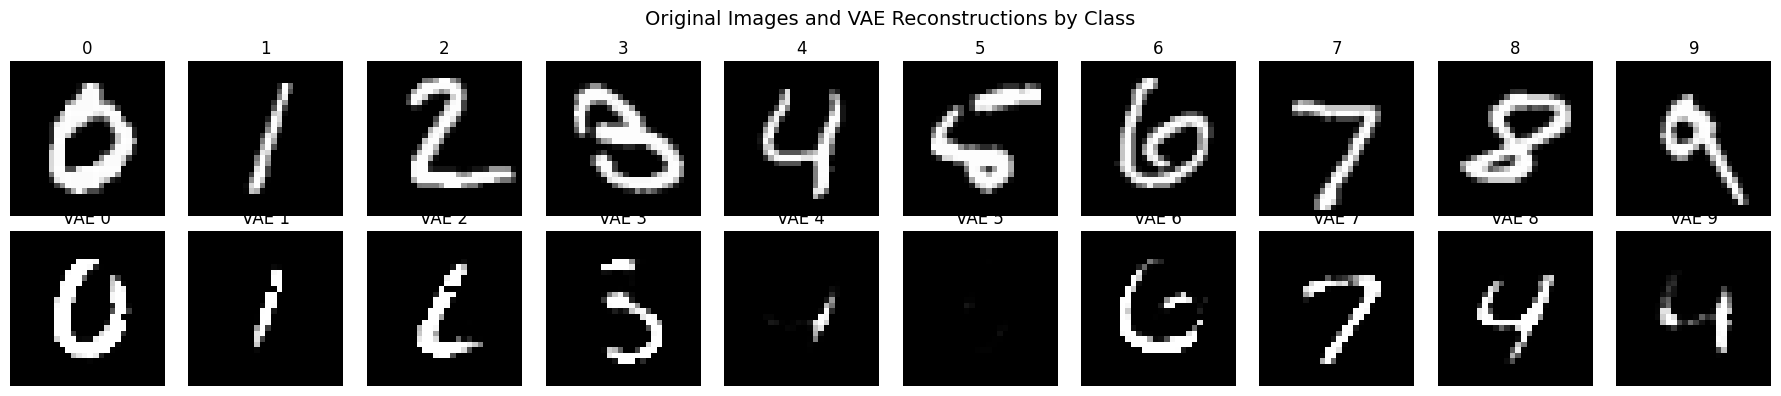

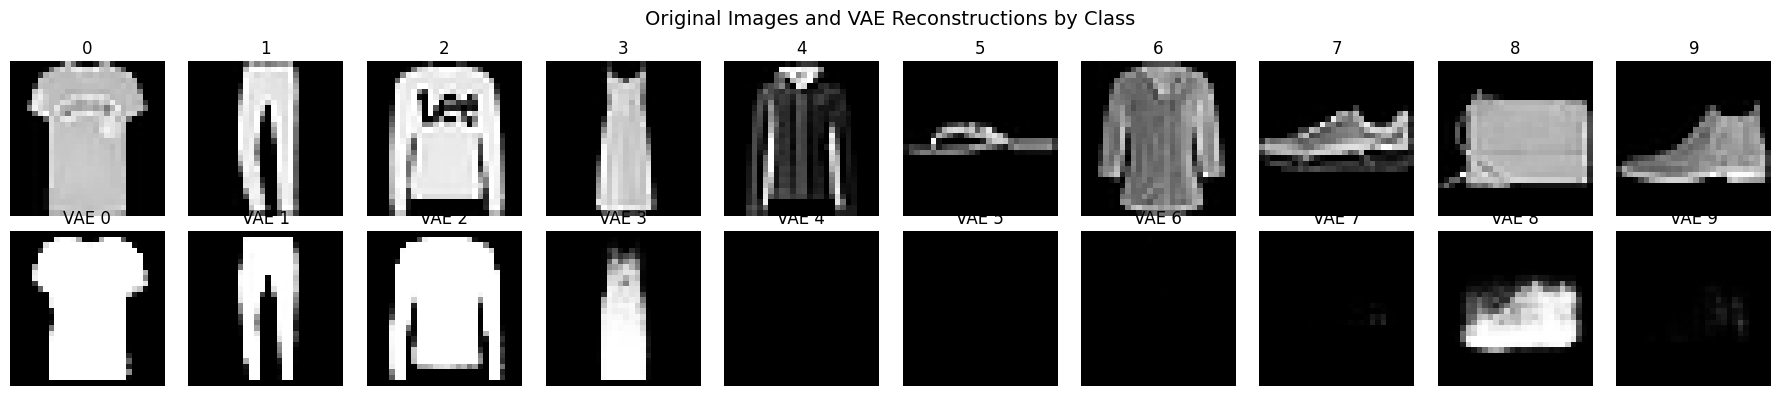

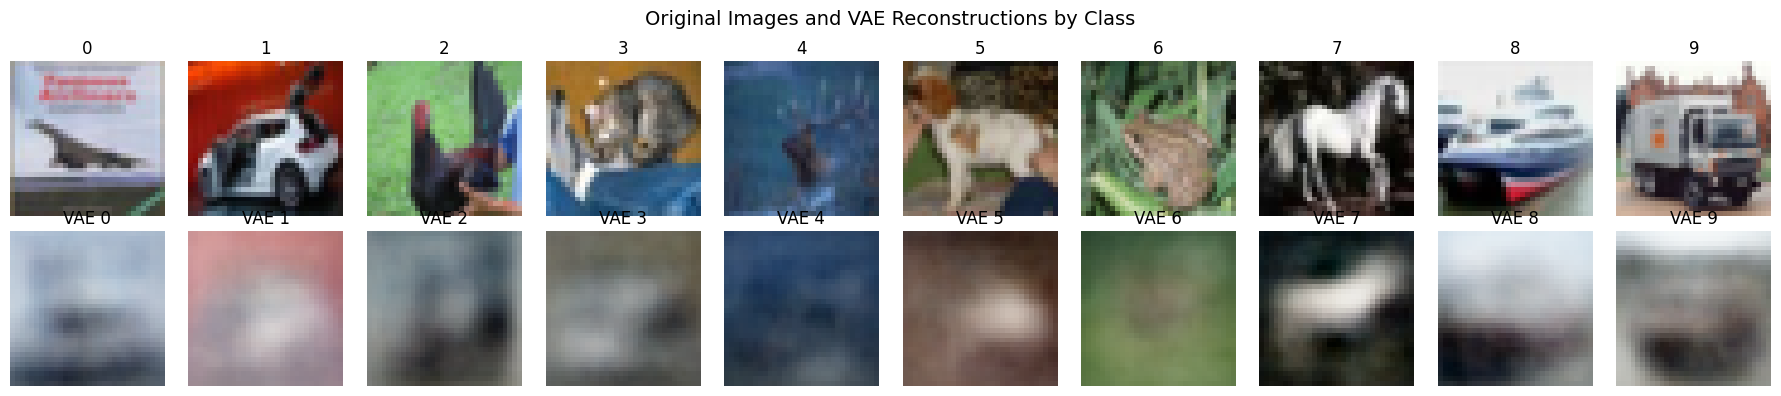

In [ ]:
# # Plotting reconstructions by class for the MP models of all 3 datasets
# plot_vae_reconstructions_by_class(model=vae_mnist_linear_mp["model"], test_loader=mnist_test, device=device, num_classes=10, cmap='gray')
# plot_vae_reconstructions_by_class(model=vae_fmnist_linear_mp["model"], test_loader=fashion_mnist_test, device=device, num_classes=10, cmap='gray')
# plot_vae_reconstructions_by_class(model=vae_cifar10_linear_mp["model"], test_loader=cifar10_test, device=device, num_classes=10, cmap=None)

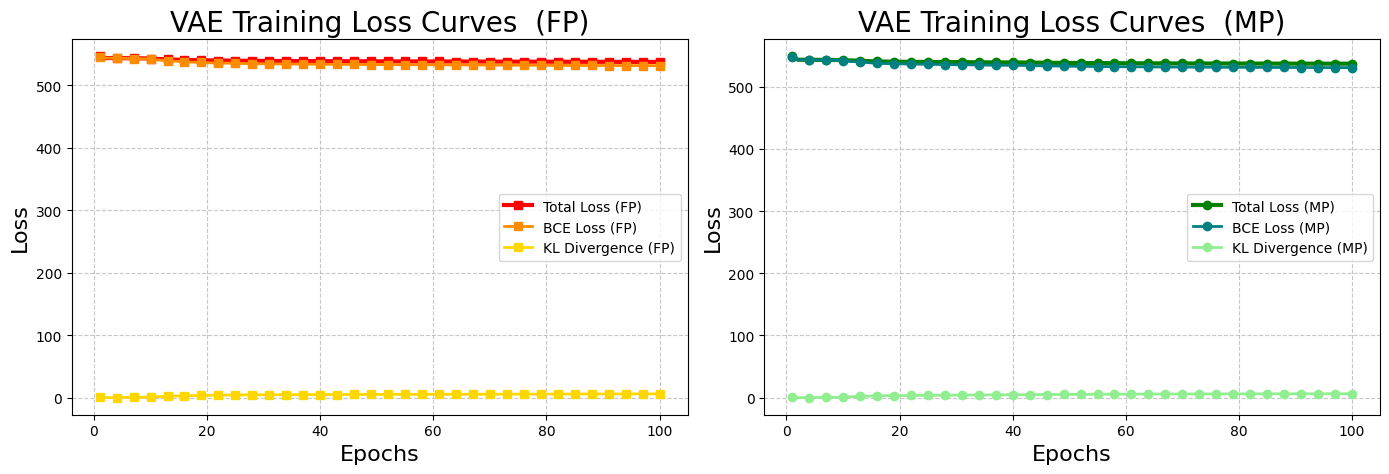

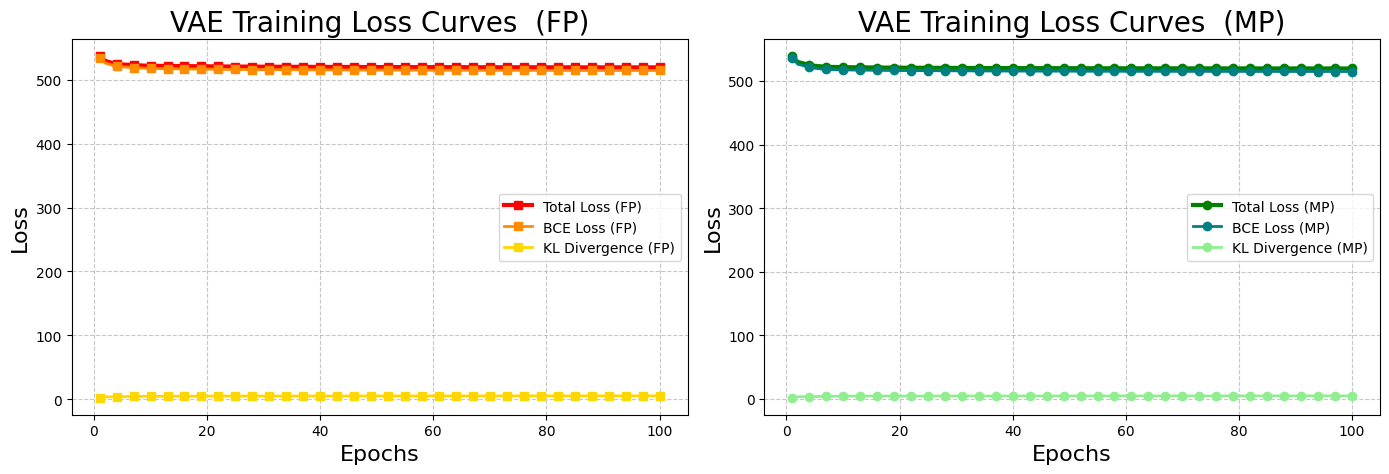

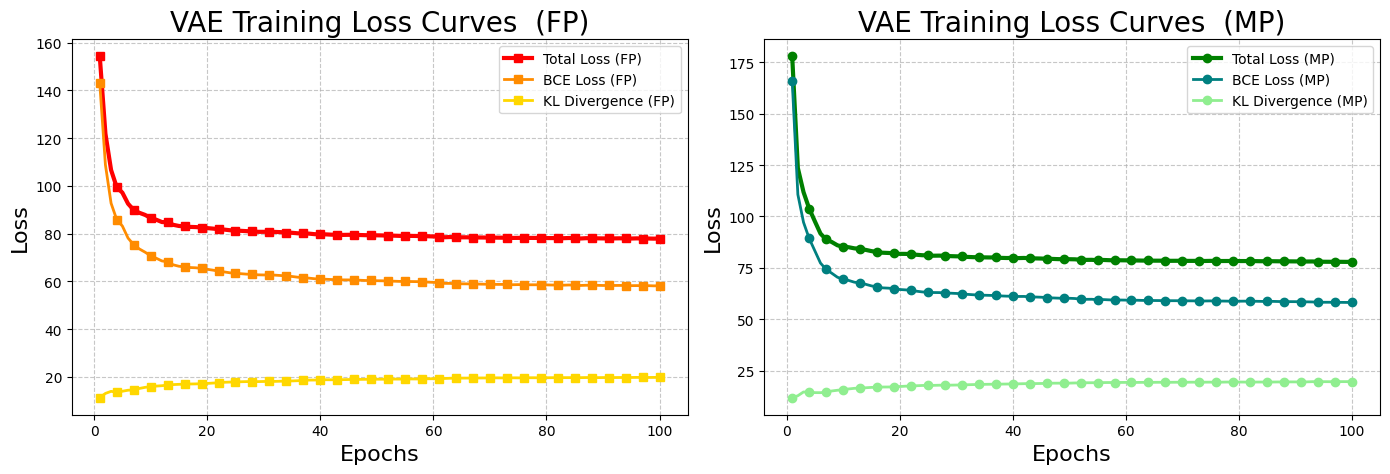

In [ ]:
# # Plotting training curves for both MP and FP models of all 3 datasets
# plot_vae_history(vae_mnist_linear_mp["history"], vae_mnist_linear_fp["history"])

# plot_vae_history(vae_fmnist_linear_mp["history"], vae_fmnist_linear_fp["history"])

# plot_vae_history(vae_cifar10_linear_mp["history"], vae_cifar10_linear_fp["history"])

========= MNIST Linear VAE Reconstructions (FP vs MP) ========= 
 === Top is original, middle row is FP recon, bottom row is MP recon ===


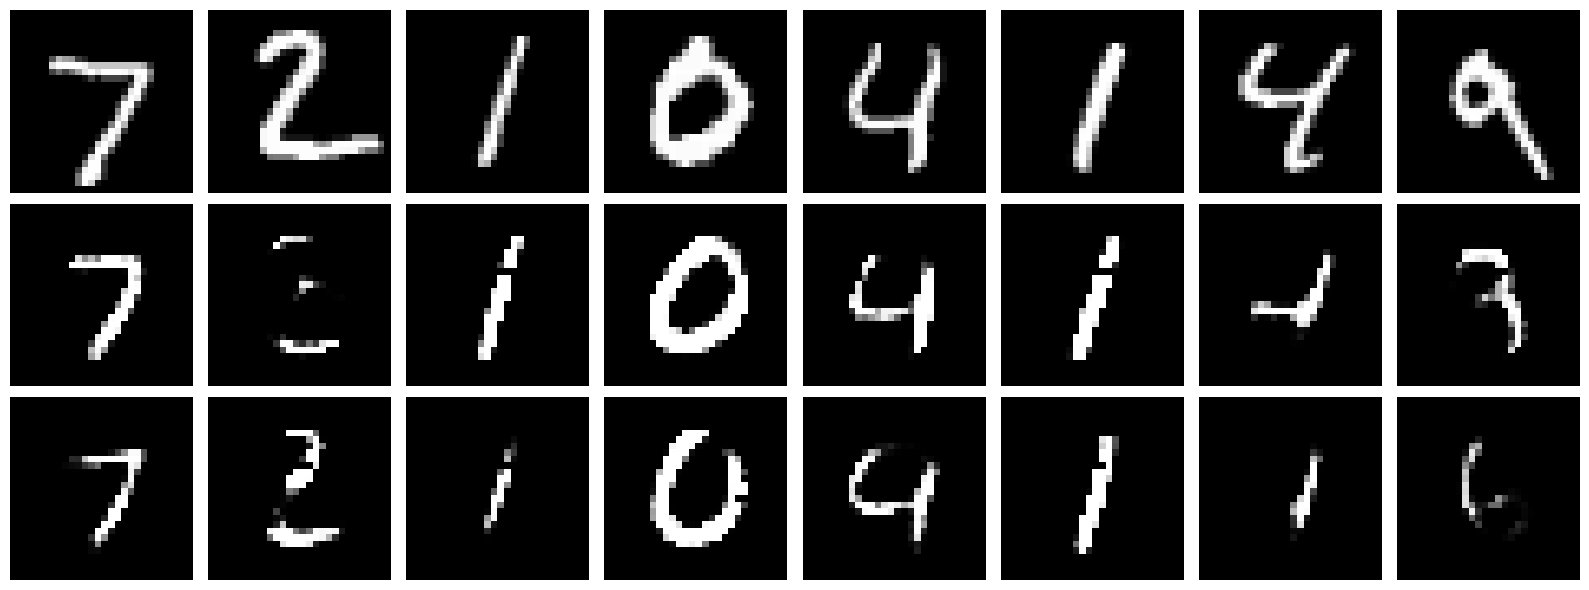

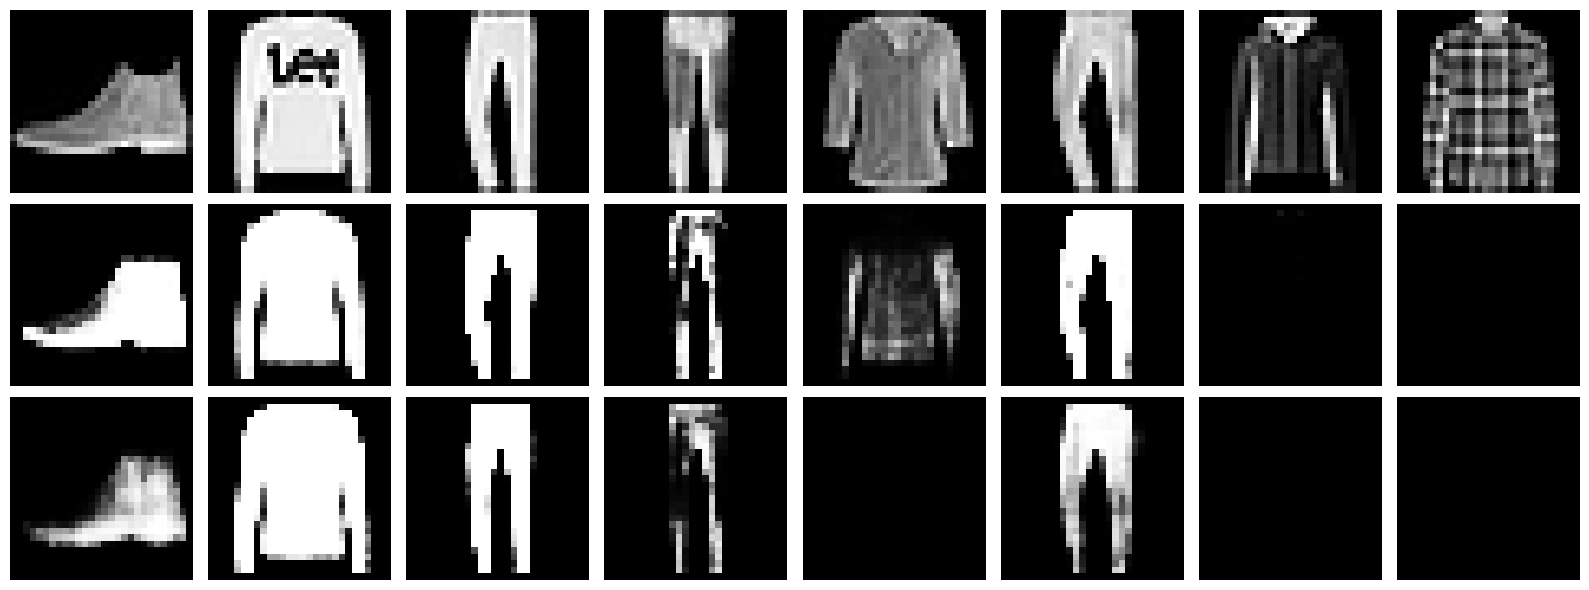

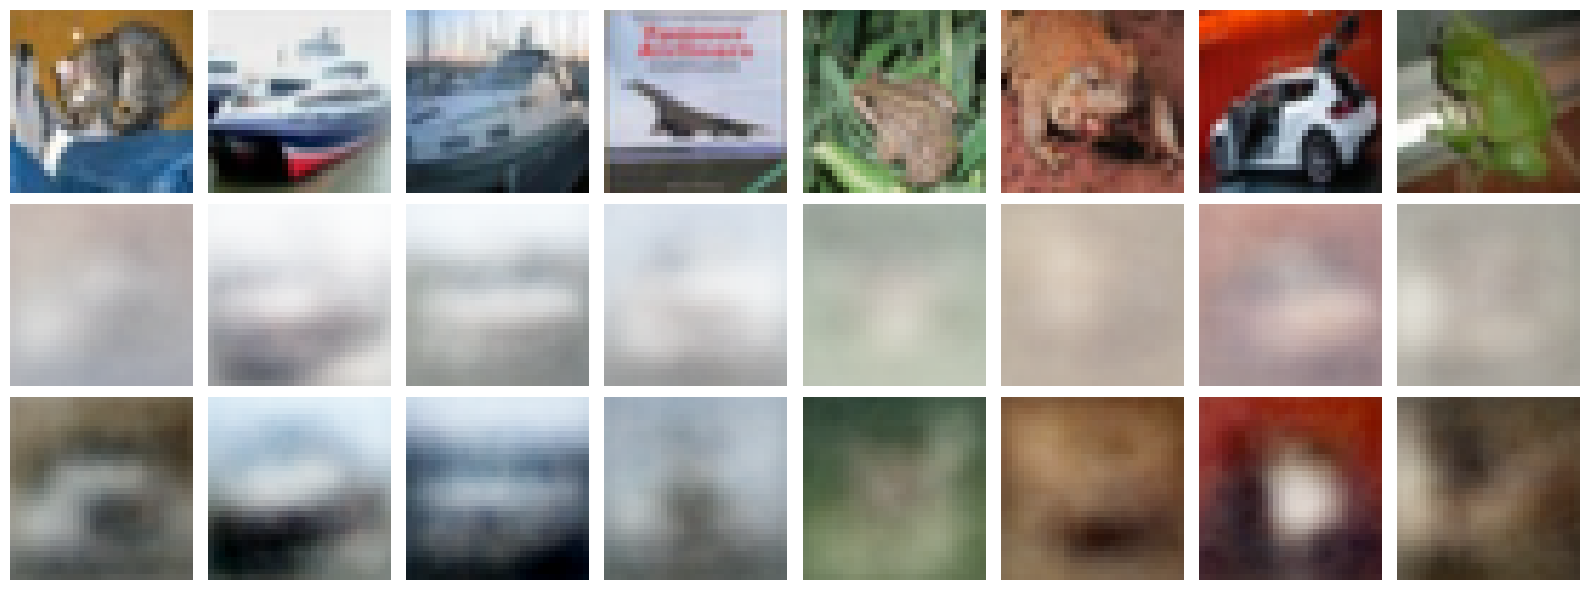

In [48]:
# linear VAE results
print("========= MNIST Linear VAE Reconstructions (FP vs MP) ========= \n === Top is original, middle row is FP recon, bottom row is MP recon ===")

show_vae_fixed_vs_mixed_results( #Top original, middle row is FP recon, bottom row is MP recon
    fixed_history=vae_mnist_linear_fp,
    mixed_history=vae_mnist_linear_mp,
    test_loader=mnist_test,
    device=device,
    dataset_name="mnist",
    num_images=8
)

show_vae_fixed_vs_mixed_results(
    fixed_history=vae_fmnist_linear_fp,
    mixed_history=vae_fmnist_linear_mp,
    test_loader=fashion_mnist_test,
    device=device,
    dataset_name="fashion-mnist",
    num_images=8
)
show_vae_fixed_vs_mixed_results(
    fixed_history=vae_cifar10_linear_fp,
    mixed_history=vae_cifar10_linear_mp,
    test_loader=cifar10_test,
    device=device,
    dataset_name="cifar10",
    num_images=8
)

========= MNIST Conv VAE Reconstructions (FP vs MP) ========= 
 === Top is original, middle row is FP recon, bottom row is MP recon ===


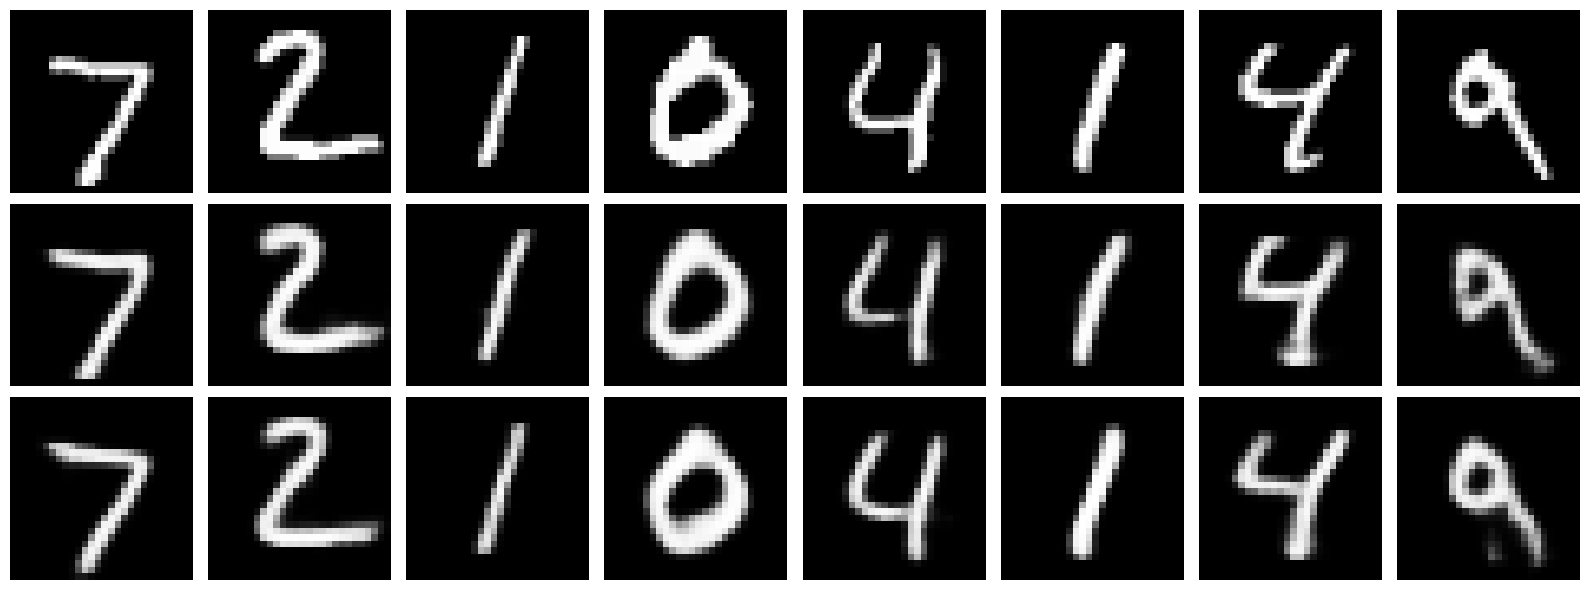

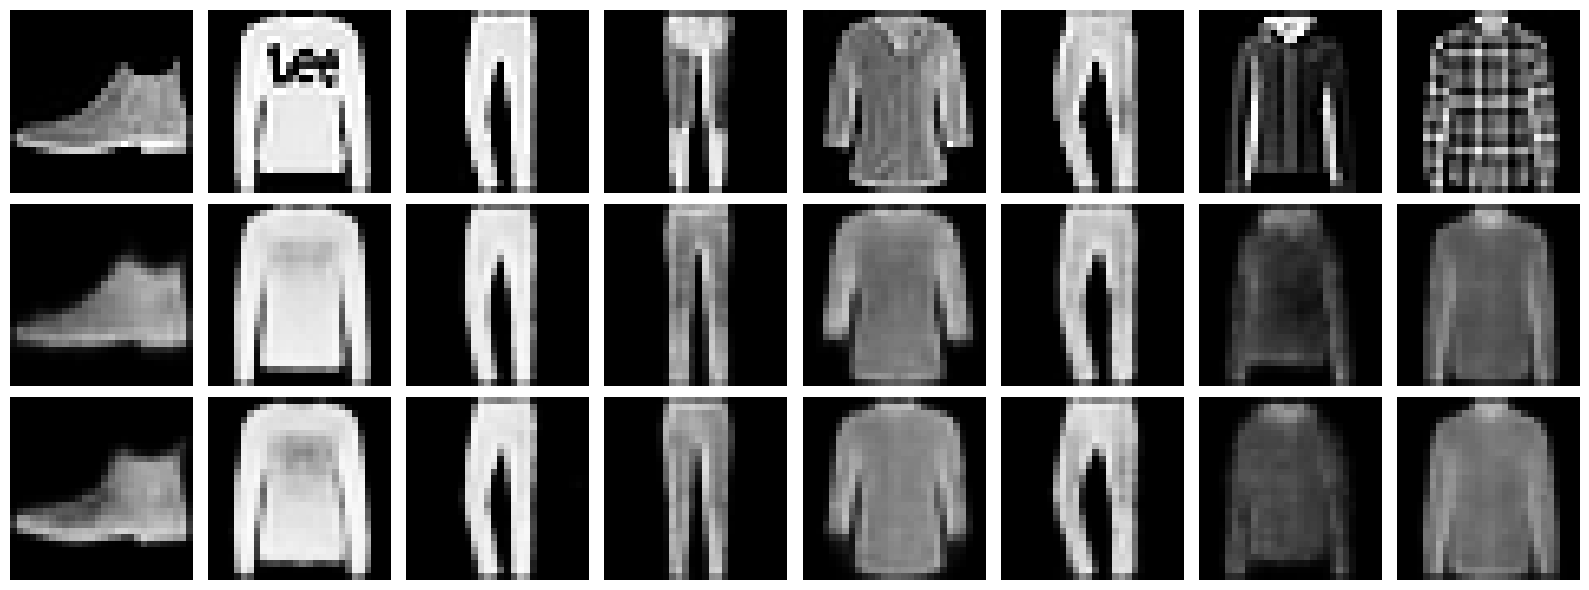

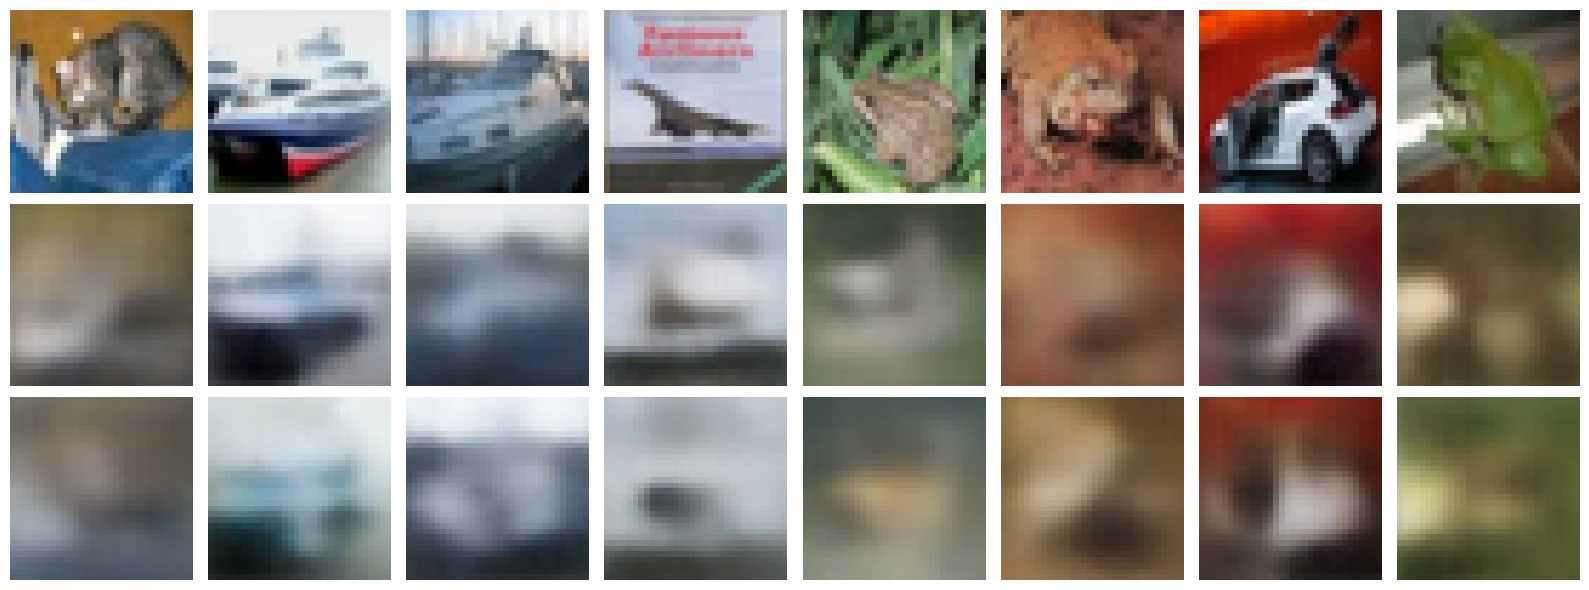

In [49]:
# And Conv VAE results
print("========= MNIST Conv VAE Reconstructions (FP vs MP) ========= \n === Top is original, middle row is FP recon, bottom row is MP recon ===")

show_vae_fixed_vs_mixed_results( #Top original, middle row is FP recon, bottom row is MP recon
    fixed_history=vae_mnist_fp,
    mixed_history=vae_mnist_mp,
    test_loader=mnist_test,
    device=device,
    dataset_name="mnist",
    num_images=8
)
show_vae_fixed_vs_mixed_results(
    fixed_history=vae_fmnist_fp,
    mixed_history=vae_fmnist_mp,
    test_loader=fashion_mnist_test,
    device=device,
    dataset_name="fashion-mnist",
    num_images=8
)
show_vae_fixed_vs_mixed_results(
    fixed_history=vae_cifar10_fp,
    mixed_history=vae_cifar10_mp,
    test_loader=cifar10_test,
    device=device,
    dataset_name="cifar10",
    num_images=8
)

# Analysis

In [50]:
# Evaluation of metrics for all models
def evaluate_reconstruction_metrics( # SSIM and PSNR
    model, 
    dataloader,
    device=DEVICE,
    output_mode="prob",   # "prob", "logits", or "tanh"
    use_mixed_precision=False,
    max_batches=None
):
    model.eval()

    psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

    autocast_enabled = use_mixed_precision and torch.cuda.is_available()
    autocast_device = "cuda" if torch.cuda.is_available() else "cpu"

    with torch.no_grad():
        for batch_idx, (x, _) in enumerate(dataloader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            x = x.to(device)

            with torch.amp.autocast(device_type=autocast_device, enabled=autocast_enabled):
                output = model(x)
                x_hat = output[0] if isinstance(output, tuple) else output

            if output_mode == "logits":
                x_hat = torch.sigmoid(x_hat)
            elif output_mode == "tanh":
                x_hat = (x_hat + 1.0) / 2.0
            elif output_mode == "prob":
                pass
            else:
                raise ValueError("output_mode must be 'prob', 'logits', or 'tanh'")

            x_hat = torch.clamp(x_hat, 0.0, 1.0)
            x = torch.clamp(x, 0.0, 1.0)

            psnr_metric.update(x_hat, x)
            ssim_metric.update(x_hat, x)
           
        print("PSNR:", psnr_metric.compute().item())
        print("SSIM:", ssim_metric.compute().item())


def _history_value(history, *keys, default=None):
    for key in keys:
        if key in history and history[key] is not None:
            return history[key]
    return default

def vae_loss(reconstructed_x, x_orig, mean, logvar, dataset_name):
    """
    Computes the VAE loss, dynamically selecting the reconstruction 
    loss based on the dataset properties.
    """
    # 1. Reconstruction Loss
    if dataset_name.lower() == "cifar10":
        # MSE is standard for continuous RGB data
        recon_loss = F.mse_loss(reconstructed_x, x_orig, reduction='sum')
    else:
        # BCE is standard for normalized grayscale data [0, 1] (MNIST/Fashion-MNIST)
        recon_loss = F.binary_cross_entropy_with_logits(reconstructed_x, x_orig, reduction='sum')

    # 2. KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    
    return recon_loss + KLD, recon_loss, KLD

def print_vae_final_metrics(loaded_model, label): # Get time and loss metrics
    history = loaded_model["history"]

    # print(f"Final Metrics {label}")
    # print(f"Training time [s]:         {_history_value(history, 'Training_time', 'training_time', default=float('nan')):.4f}")
    # print(f"Final train recon loss:    {history['bce_loss'][-1]:.4f}")
    # print(f"Final train KL loss:       {history['kld_loss'][-1]:.4f}")
    # print(f"Final train total loss:    {history['train_loss'][-1]:.4f}")
    return {
        "training_time": _history_value(history, 'Training_time', 'training_time', default=float('nan')),
        "final_train_recon_loss": history['bce_loss'][-1],
        "final_train_kl_loss": history['kld_loss'][-1],
        "final_train_total_loss": history['train_loss'][-1],
    }


def evaluate_vae_test_losses(model, test_loader, dataset_name, device, use_mixed_precision=False):
    # Evaluate VAE performance on the test set
    model.eval()
    total_loss = 0.0
    total_recon = 0.0
    total_kld = 0.0
    n_samples = 0

    autocast_enabled = use_mixed_precision and (device.type == "cuda")

    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            bsz = x.size(0)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=autocast_enabled):
                x_hat, mean, logvar = model(x)
                loss, recon, kld = vae_loss(x_hat, x, mean, logvar, dataset_name)

            total_loss += loss.item()
            total_recon += recon.item()
            total_kld += kld.item()
            n_samples += bsz

    return {
        "test_total_loss": total_loss / n_samples,
        "test_recon_loss": total_recon / n_samples,
        "test_kld_loss": total_kld / n_samples,
    }    

In [53]:
results = {}

results["conv_mnist_fp"] = {**evaluate_vae_test_losses(vae_mnist_fp["model"], mnist_test, "mnist", device, use_mixed_precision=False), **print_vae_final_metrics(vae_mnist_fp, "Conv MNIST FP")}
results["conv_mnist_mp"] = {**evaluate_vae_test_losses(vae_mnist_mp["model"], mnist_test, "mnist", device, use_mixed_precision=True), **print_vae_final_metrics(vae_mnist_mp, "Conv MNIST MP")}
    
results["conv_fmnist_fp"] = {**evaluate_vae_test_losses(vae_fmnist_fp["model"], fashion_mnist_test, "fashion-mnist", device, use_mixed_precision=False), **print_vae_final_metrics(vae_fmnist_fp, "Conv Fashion-MNIST FP")}
results["conv_fmnist_mp"] = {**evaluate_vae_test_losses(vae_fmnist_mp["model"], fashion_mnist_test, "fashion-mnist", device, use_mixed_precision=True), **print_vae_final_metrics(vae_fmnist_mp, "Conv Fashion-MNIST MP")}


results["conv_cifar_fp"] = {**evaluate_vae_test_losses(vae_cifar10_fp["model"], cifar10_test, "cifar10", device, use_mixed_precision=False), **print_vae_final_metrics(vae_cifar10_fp, "Conv CIFAR-10 FP")}
results["conv_cifar_mp"] = {**evaluate_vae_test_losses(vae_cifar10_mp["model"], cifar10_test, "cifar10", device, use_mixed_precision=True), **print_vae_final_metrics(vae_cifar10_mp, "Conv CIFAR-10 MP")}

pd.DataFrame(results).T

,test_total_loss,test_recon_loss,test_kld_loss,training_time,final_train_recon_loss,final_train_kl_loss,final_train_total_loss
conv_mnist_fp,98.375464,73.029573,25.345892,512.169125,72.571148,25.813243,98.384391
conv_mnist_mp,98.269413,72.620309,25.649104,525.113646,72.586250,25.784845,98.371095
conv_fmnist_fp,240.132241,222.742165,17.390077,509.276813,220.611306,17.419721,238.031027
conv_fmnist_mp,240.227990,223.042938,17.185053,522.564495,220.719518,17.323067,238.042584
conv_cifar_fp,73.967447,51.495884,22.471563,510.835952,50.568852,22.862886,73.431738
conv_cifar_mp,74.093286,51.301173,22.792113,532.075485,50.574053,22.949833,73.523886


In [54]:
# And for linear
results = {}

results["linear_mnist_fp"] = {**evaluate_vae_test_losses(vae_mnist_fp["model"], mnist_test, "mnist", device, use_mixed_precision=False), **print_vae_final_metrics(vae_mnist_fp, "Linear MNIST FP")}
results["linear_mnist_mp"] = {**evaluate_vae_test_losses(vae_mnist_mp["model"], mnist_test, "mnist", device, use_mixed_precision=True), **print_vae_final_metrics(vae_mnist_mp, "Linear MNIST MP")}

results["linear_fmnist_fp"] = {**evaluate_vae_test_losses(vae_fmnist_fp["model"], fashion_mnist_test, "fashion-mnist", device, use_mixed_precision=False), **print_vae_final_metrics(vae_fmnist_fp, "Linear Fashion-MNIST FP")}
results["linear_fmnist_mp"] = {**evaluate_vae_test_losses(vae_fmnist_mp["model"], fashion_mnist_test, "fashion-mnist", device, use_mixed_precision=True), **print_vae_final_metrics(vae_fmnist_mp, "Linear Fashion-MNIST MP")}


results["linear_cifar_fp"] = {**evaluate_vae_test_losses(vae_cifar10_fp["model"], cifar10_test, "cifar10", device, use_mixed_precision=False), **print_vae_final_metrics(vae_cifar10_fp, "Linear CIFAR-10 FP")}
results["linear_cifar_mp"] = {**evaluate_vae_test_losses(vae_cifar10_mp["model"], cifar10_test, "cifar10", device, use_mixed_precision=True), **print_vae_final_metrics(vae_cifar10_mp, "Linear CIFAR-10 MP")}

pd.DataFrame(results).T


,test_total_loss,test_recon_loss,test_kld_loss,training_time,final_train_recon_loss,final_train_kl_loss,final_train_total_loss
linear_mnist_fp,98.332498,72.986607,25.345892,512.169125,72.571148,25.813243,98.384391
linear_mnist_mp,98.262463,72.613359,25.649104,525.113646,72.586250,25.784845,98.371095
linear_fmnist_fp,240.127663,222.737587,17.390077,509.276813,220.611306,17.419721,238.031027
linear_fmnist_mp,240.127913,222.942862,17.185053,522.564495,220.719518,17.323067,238.042584
linear_cifar_fp,73.998384,51.526820,22.471563,510.835952,50.568852,22.862886,73.431738
linear_cifar_mp,73.972133,51.180020,22.792113,532.075485,50.574053,22.949833,73.523886
